In [2]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.style
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.cm as cmx
mpl.style.use('classic')

import baraffe_tables
from baraffe_tables.table_search import baraffe_table_search

from astropy.table import Table
from astropy import units as u
from astropy.constants import G

import mesa_helper as mh
import os
import shutil

%matplotlib inline

In [43]:
# import Asplund table
MH_arr = np.array((-0.3,0.0,0.3,0.7,1.0,1.5,1.7))
MH_arr_siebenaler = np.array((-0.5,-0.3,0.0,0.3,0.51,0.72,1.05,1.75,2.21))
Nratio_arr = 10**MH_arr
print(Nratio_arr)

[ 0.50118723  1.          1.99526231  5.01187234 10.         31.6227766
 50.11872336]


In [44]:
! ls

2003_lodders.pdf        asplund+2021_table2.txt convention.pdf
M_H_to_Z.ipynb          atomic_masses.txt       lodders2003_table2.txt


In [45]:
asplund = Table.read("./asplund+2021_table2.txt",data_start=1,format='ascii')
print(asplund)
#asplund = asplund[np.argsort(asplund['Z'])]
#asplund.write("./asplund+2021_table2.txt",format='ascii',overwrite=True)

lodders = Table.read("./lodders2003_table2.txt",data_start=1,format='ascii')
print(lodders)
#lodders = lodders[np.argsort(lodders['Z'])]
#lodders.write("./lodders2003_table2.txt",format='ascii',overwrite=True)

atomic_masses = Table.read("./atomic_masses.txt",data_start=1,format='ascii')
print(atomic_masses)

 Z  Element Photosphere Photosphere_unc CIchondrites CIchondrites_unc
--- ------- ----------- --------------- ------------ ----------------
  1       H        12.0             0.0         8.22             0.04
  2      He      10.914           0.013         1.29             0.18
  3      Li        0.96            0.06         3.25             0.04
  4      Be        1.38            0.09         1.32             0.03
  5       B         2.7             0.2         2.79             0.04
  6       C        8.46            0.04         7.39             0.04
  7       N        7.83            0.07         6.26             0.06
  8       O        8.69            0.04         8.39             0.04
  9       F         4.4            0.25         4.42             0.06
 10      Ne        8.06            0.05        −1.12             0.18
...     ...         ...             ...          ...              ...
 76      Os        1.35            0.12         1.35             0.02
 77      Ir         

In [46]:
asplund['atomic_mass'] = np.zeros_like(asplund['Photosphere'])
lodders['atomic_mass'] = np.zeros_like(lodders['A_0'])

for i in range(len(asplund['atomic_mass'])):
    this_Z = asplund['Z'][i]
    this_atomic_mass = atomic_masses['Atomic_mass[u]'][atomic_masses['Z'] == this_Z][0]
    asplund['atomic_mass'][i] = this_atomic_mass


for i in range(len(lodders['atomic_mass'])):
    this_Z = lodders['Z'][i]
    this_atomic_mass = atomic_masses['Atomic_mass[u]'][atomic_masses['Z'] == this_Z][0]
    lodders['atomic_mass'][i] = this_atomic_mass


In [47]:
print(asplund)
print(lodders)

 Z  Element Photosphere ... CIchondrites CIchondrites_unc atomic_mass
--- ------- ----------- ... ------------ ---------------- -----------
  1       H        12.0 ...         8.22             0.04       1.008
  2      He      10.914 ...         1.29             0.18      4.0026
  3      Li        0.96 ...         3.25             0.04        6.94
  4      Be        1.38 ...         1.32             0.03      9.0122
  5       B         2.7 ...         2.79             0.04       10.81
  6       C        8.46 ...         7.39             0.04      12.011
  7       N        7.83 ...         6.26             0.06      14.007
  8       O        8.69 ...         8.39             0.04      15.999
  9       F         4.4 ...         4.42             0.06      18.998
 10      Ne        8.06 ...        −1.12             0.18       20.18
...     ...         ... ...          ...              ...         ...
 76      Os        1.35 ...         1.35             0.02      190.23
 77      Ir         

In [48]:
def metal_mass_fraction(M_H, table='asplund'):
    print(M_H, 10**M_H)

    if table == 'asplund':
        # convert tabulated solar abundances to number fractions
        nj_over_nH = 10**(asplund['Photosphere'] - 12.)
        # enhance/deplete metal species only
        nj_over_nH[2:] = 10**M_H * nj_over_nH[2:]

        # convert to mass fractions
        nH_over_Mtot = 1./np.sum(nj_over_nH * asplund['atomic_mass'])

        X = asplund['atomic_mass'][0] * nH_over_Mtot
        Y = asplund['atomic_mass'][1] * nj_over_nH[1] * nH_over_Mtot
        Z = np.sum(nj_over_nH[2:] * asplund['atomic_mass'][2:]) * nH_over_Mtot      

    elif table == 'lodders':
        # convert tabulated solar abundances to number fractions
        nj_over_nH = 10**(lodders['A_0'] - 12.)
        # enhance/deplete metal species only
        nj_over_nH[2:] = 10**M_H * nj_over_nH[2:]

        # convert to mass fractions
        nH_over_Mtot = 1./np.sum(nj_over_nH * lodders['atomic_mass'])

        X = lodders['atomic_mass'][0] * nH_over_Mtot
        Y = lodders['atomic_mass'][1] * nj_over_nH[1] * nH_over_Mtot
        Z = np.sum(nj_over_nH[2:] * lodders['atomic_mass'][2:]) * nH_over_Mtot      

    #print(X,Y,Z, X+Y+Z)
    return X, Y, Z


In [53]:
X_arr_asplund = np.zeros_like(MH_arr_siebenaler)
X_arr_lodders = np.zeros_like(MH_arr_siebenaler)

Y_arr_asplund = np.zeros_like(MH_arr_siebenaler)
Y_arr_lodders = np.zeros_like(MH_arr_siebenaler)

Z_arr_asplund = np.zeros_like(MH_arr_siebenaler)
Z_arr_lodders = np.zeros_like(MH_arr_siebenaler)

for i, mh in enumerate(MH_arr_siebenaler):
    print(mh, 10**mh)
    X_a, Y_a, Z_a = metal_mass_fraction(M_H=mh, table='asplund')
    X_arr_asplund[i] = X_a
    Y_arr_asplund[i] = Y_a
    Z_arr_asplund[i] = Z_a

    X_l, Y_l, Z_l = metal_mass_fraction(M_H=mh, table='lodders')
    X_arr_lodders[i] = X_l
    Y_arr_lodders[i] = Y_l
    Z_arr_lodders[i] = Z_l


-0.5 0.31622776601683794
-0.5 0.31622776601683794
-0.5 0.31622776601683794
-0.3 0.5011872336272722
-0.3 0.5011872336272722
-0.3 0.5011872336272722
0.0 1.0
0.0 1.0
0.0 1.0
0.3 1.9952623149688795
0.3 1.9952623149688795
0.3 1.9952623149688795
0.51 3.2359365692962827
0.51 3.2359365692962827
0.51 3.2359365692962827
0.72 5.248074602497725
0.72 5.248074602497725
0.72 5.248074602497725
1.05 11.220184543019636
1.05 11.220184543019636
1.05 11.220184543019636
1.75 56.23413251903491
1.75 56.23413251903491
1.75 56.23413251903491
2.21 162.18100973589299
2.21 162.18100973589299
2.21 162.18100973589299


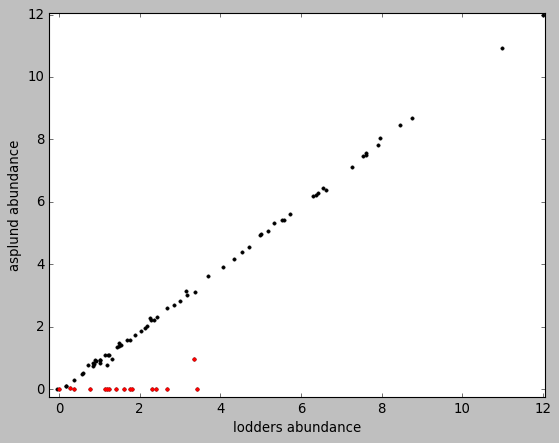

Li Li
As As
Se Se
Br Br
Rh Rh
Pd Pd
Ag Ag
Cd Cd
Sb Sb
Te Te
I I
Cs Cs
La La
Pr Pr
Eu Eu
Tb Tb
Ho Ho
Tm Tm
Yb Yb
Lu Lu
Re Re
Ir Ir
Pt Pt
Hg Hg
Bi Bi
Th Th
U U


In [54]:
fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.plot(lodders['A_0'],asplund['Photosphere'],'k.')
diff_mask = (asplund['Photosphere'] <= 0.5*lodders['A_0'])
ax.plot(lodders['A_0'][diff_mask],asplund['Photosphere'][diff_mask],'r.')
ax.set_xlabel('lodders abundance')
ax.set_ylabel('asplund abundance')
ax.set_xlim(-0.25,12.05)
ax.set_ylim(-0.25,12.05)
plt.show()

for i in range(len(lodders['A_0'])):
    if asplund['Photosphere'][i] <= 0.9*lodders['A_0'][i]:
        print(lodders['Element'][i],asplund['Element'][i])

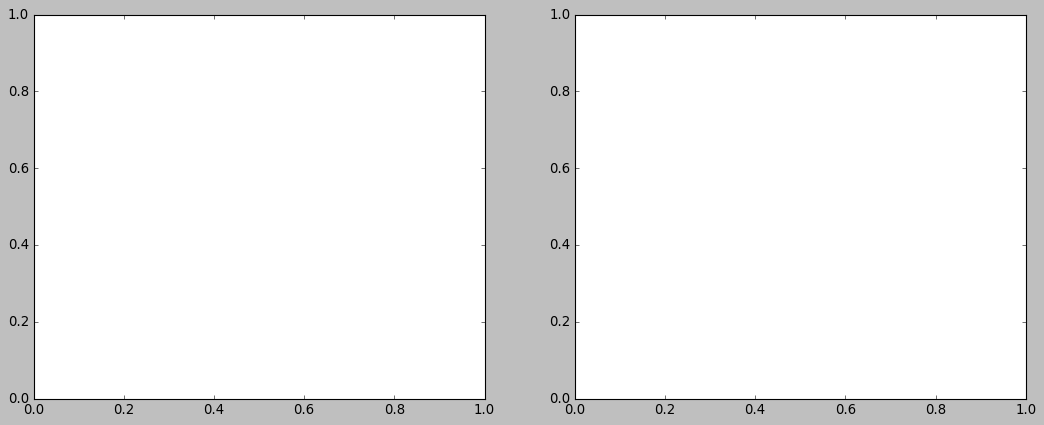

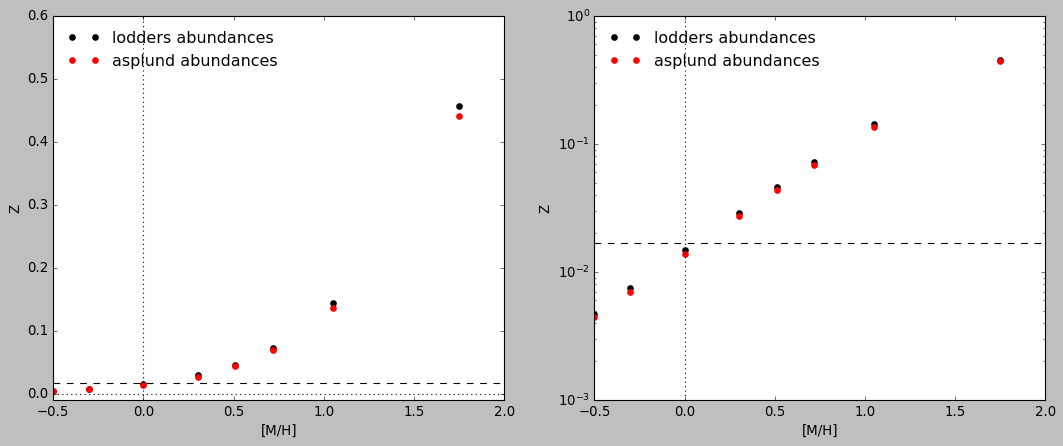

0.007452349596041253
0.007008242149159932


In [56]:
fig, axes = plt.subplots(1,2,figsize=(16,6))
for ax in axes:
    ax.plot(MH_arr_siebenaler, Z_arr_lodders,'ko',mec='None',label='lodders abundances')
    ax.plot(MH_arr_siebenaler, Z_arr_asplund,'ro',mec='None',label='asplund abundances')
    ax.set_xlabel('[M/H]')
    ax.set_ylabel('Z')
    ax.set_xlim(-0.5,2)
    ax.axhline(0.017,color='k',ls='--')
    ax.axvline(0.,color='k',ls=':')
    ax.legend(loc='upper left',frameon=False)
    
axes[0].set_ylim(-0.01,0.6)
axes[0].axhline(0.,color='k',ls=':')
axes[1].set_yscale('log')

plt.show()

# solar metal mass fraction
print(Z_arr_lodders[1])
print(Z_arr_asplund[1])

In [82]:
print(X_arr_lodders)
print(Y_arr_lodders)
print("")
print(Y_arr_lodders/X_arr_lodders)
print("")
print(Z_arr_lodders)
print(X_arr_lodders + Y_arr_lodders + Z_arr_lodders)

[0.71980198 0.71782236 0.71253744 0.70222181 0.68977337 0.67049648
 0.61914064 0.39252828 0.21087113]
[0.27548293 0.27472529 0.27270264 0.26875464 0.26399037 0.25661271
 0.23695778 0.1502286  0.08070469]

[0.38272044 0.38272044 0.38272044 0.38272044 0.38272044 0.38272044
 0.38272044 0.38272044 0.38272044]

[0.00471508 0.00745235 0.01475992 0.02902355 0.04623626 0.0728908
 0.14390158 0.45724313 0.70842417]
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [83]:
print(X_arr_asplund)
print(Y_arr_asplund)
print("")
print(Y_arr_asplund/X_arr_asplund)
print("")
print(Z_arr_asplund)
print(X_arr_asplund + Y_arr_asplund + Z_arr_asplund)

[0.75094715 0.74900495 0.7438168  0.73367692 0.72141739 0.70238284
 0.65137279 0.42094787 0.22969873]
[0.24461948 0.24398681 0.24229678 0.23899373 0.23500022 0.22879975
 0.21218334 0.1371229  0.07482389]

[0.32574793 0.32574793 0.32574793 0.32574793 0.32574793 0.32574793
 0.32574793 0.32574793 0.32574793]

[0.00443337 0.00700824 0.01388642 0.02732935 0.04358239 0.06881741
 0.13644387 0.44192923 0.69547738]
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [59]:
print(np.round(Z_arr_lodders,5))

[0.00472 0.00745 0.01476 0.02902 0.04624 0.07289 0.1439  0.45724 0.70842]


In [63]:
test = np.round(Z_arr_lodders,3)
print(test)

[0.005 0.007 0.015 0.029 0.046 0.073 0.144 0.457 0.708]


In [64]:
print(np.floor(test*1.e5 + 0.1))

[  500.   700.  1500.  2900.  4600.  7300. 14400. 45700. 70800.]


In [3]:
# rename Louis tables to reflect different [M/H] convention (see convention.pdf in this directory)

In [11]:
'''
equ_dir = "/Users/emily/mesa-24.08.1/kap/preprocessor/kap_input_data/siebenaler_cloudy_equ_cond"
rainout_dir = "/Users/emily/mesa-24.08.1/kap/preprocessor/kap_input_data/siebenaler_cloudy_rainout"

eqch_files = [f for f in os.listdir(equ_dir) if os.path.isfile(os.path.join(equ_dir, f)) and ".dat" in f]
rain_files = [f for f in os.listdir(rainout_dir) if os.path.isfile(os.path.join(rainout_dir, f)) and ".dat" in f]

#for f in eqch_files:
for f in rain_files:
    if "+0.5" in f:
        print(f)
        new_fname = f.split("+")[0] + "+0.51_" + f.split("_")[-1]
        print(new_fname)

    elif "+0.7" in f:
        print(f)
        new_fname = f.split("+")[0] + "+0.72_" + f.split("_")[-1]
        print(new_fname)

    elif "+1.0" in f:
        print(f)
        new_fname = f.split("+")[0] + "+1.05_" + f.split("_")[-1]
        print(new_fname)

    elif "+1.5" in f:
        print(f)
        new_fname = f.split("+")[0] + "+1.75_" + f.split("_")[-1]
        print(new_fname)

    elif "+1.7" in f:
        print(f)
        new_fname = f.split("+")[0] + "+2.21_" + f.split("_")[-1]
        print(new_fname)
    
    #os.system('mv {0}/{1} {0}/{2}'.format(equ_dir,f,new_fname))
    os.system('mv {0}/{1} {0}/{2}'.format(rainout_dir,f,new_fname))
'''

LS25_c10_+1.7_rainout.dat
LS25_c10_+2.21_rainout.dat
LS25_c2_+0.7_rainout.dat
LS25_c2_+0.72_rainout.dat
LS25_c5_+1.7_rainout.dat
LS25_c5_+2.21_rainout.dat
LS25_c2_+1.0_rainout.dat
LS25_c2_+1.05_rainout.dat
LS25_c1_+0.5_rainout.dat
LS25_c1_+0.51_rainout.dat
LS25_c50_+0.5_rainout.dat
LS25_c50_+0.51_rainout.dat
LS25_c2_+1.5_rainout.dat
LS25_c2_+1.75_rainout.dat
LS25_c5_+0.5_rainout.dat
LS25_c5_+0.51_rainout.dat
LS25_c10_+0.5_rainout.dat
LS25_c10_+0.51_rainout.dat
LS25_c1_+1.7_rainout.dat
LS25_c1_+2.21_rainout.dat
LS25_c50_+1.7_rainout.dat
LS25_c50_+2.21_rainout.dat
LS25_c0.1_+1.5_rainout.dat
LS25_c0.1_+1.75_rainout.dat
LS25_c0.5_+1.0_rainout.dat
LS25_c0.5_+1.05_rainout.dat
LS25_c0.01_+1.7_rainout.dat
LS25_c0.01_+2.21_rainout.dat
LS25_c0.5_+0.7_rainout.dat
LS25_c0.5_+0.72_rainout.dat
LS25_c0.05_+0.5_rainout.dat
LS25_c0.05_+0.51_rainout.dat
LS25_c0.01_+0.5_rainout.dat
LS25_c0.01_+0.51_rainout.dat
LS25_c0.1_+0.7_rainout.dat
LS25_c0.1_+0.72_rainout.dat
LS25_c0.05_+1.7_rainout.dat
LS25_c0.05_+

In [120]:
louis_Zs = np.array((0.0044, 0.007, 0.0139, 0.0273, 0.0426, 0.0659, 0.1234, 0.3081, 0.4138, 0.4419, 0.5847, 0.6955))
print(np.floor(louis_Zs*1.e5 + 0.1))


[  440.   700.  1390.  2730.  4260.  6590. 12340. 30810. 41380. 44190.
 58470. 69550.]


In [122]:
print(np.log10(5800))
print(np.log10(6000))

3.7634279935629373
3.7781512503836434


In [19]:
logTmin = 1.88
logTmax = 4.5
logrhomin = -10
logrhomax = -2.7

logRmin = logrhomin - 3*logTmax + 18
logRmax = logrhomax - 3*logTmin + 18

print(logRmin,logRmax)

-5.5 9.66


In [112]:
example_s = "/Users/emily/mesa-24.08.1/kap/preprocessor/kap_input_data/siebenaler_cloudfree_rainout/LS26_cf_-0.3_rainout_TRHO.dat"
s_m03 = np.genfromtxt(example_s,skip_header=24)
print(np.shape(s_m03))

siebenaler_T = np.unique(s_m03[:,0])
siebenaler_rho = np.unique(s_m03[:,1])

print(len(siebenaler_rho))

ferguson_T = np.array((2.70000, 2.75000, 2.80000, 2.85000, 2.90000, 2.91000, 2.92000, 2.93000, 2.94000, 2.95000, 2.96000, 2.97000, 2.98000, 2.99000, 3.00000, 3.01000, 3.02000, 3.03000, 3.04000, 3.05000, 3.06000, 3.07000, 3.08000, 3.09000, 3.10000, 3.11000, 3.12000, 3.13000, 3.14000, 3.15000, 3.16000, 3.17000, 3.18000, 3.19000, 3.20000, 3.21000, 3.22000, 3.23000, 3.24000, 3.25000, 3.26000, 3.27000, 3.28000, 3.29000, 3.30000, 3.31000, 3.32000, 3.33000, 3.34000, 3.35000, 3.36000, 3.37000, 3.38000, 3.39000, 3.40000, 3.41000, 3.42000, 3.43000, 3.44000, 3.45000, 3.46000, 3.47000, 3.48000, 3.49000, 3.50000, 3.52500, 3.55000, 3.57500, 3.60000, 3.62500, 3.65000, 3.67500, 3.70000, 3.72500, 3.75000, 3.77500, 3.80000, 3.82500, 3.85000, 3.87500, 3.90000, 3.92500, 3.95000, 3.97500, 4.00000, 4.02500, 4.05000, 4.07500, 4.10000, 4.12500, 4.15000, 4.17500, 4.20000, 4.22500, 4.25000, 4.27500, 4.30000, 4.32500, 4.35000, 4.37500, 4.40000, 4.42500, 4.45000, 4.47500, 4.50000))

combined_T = np.sort(np.unique(np.concatenate((siebenaler_T,ferguson_T))))
print(combined_T)
print(len(combined_T))

(1293, 15)
28
[2.      2.09691 2.17609 2.30103 2.39794 2.47712 2.54407 2.60206 2.65321
 2.69897 2.7     2.75    2.77815 2.8     2.8451  2.85    2.9     2.90309
 2.91    2.92    2.93    2.94    2.95    2.95424 2.96    2.97    2.98
 2.99    3.      3.01    3.02    3.03    3.04    3.04139 3.05    3.06
 3.07    3.07918 3.08    3.09    3.1     3.11    3.11394 3.12    3.13
 3.14    3.14613 3.15    3.16    3.17    3.17609 3.18    3.19    3.2
 3.20412 3.21    3.22    3.23    3.23045 3.24    3.25    3.25527 3.26
 3.27    3.27875 3.28    3.29    3.3     3.30103 3.31    3.32    3.32222
 3.33    3.34    3.34242 3.35    3.36    3.36173 3.37    3.38    3.38021
 3.39    3.39794 3.4     3.41    3.41497 3.42    3.43    3.43136 3.44
 3.44716 3.45    3.46    3.4624  3.47    3.47712 3.48    3.49    3.5
 3.50515 3.525   3.53148 3.55    3.5563  3.575   3.57978 3.6     3.60206
 3.62325 3.625   3.64345 3.65    3.66276 3.675   3.68124 3.69897 3.7
 3.725   3.74036 3.75    3.775   3.77815 3.8     3.825   3.85   

In [117]:
siebenaler_R = s_m03[:,1] - 3*s_m03[:,0] + 18
print(np.sort(siebenaler_R))
print(len(siebenaler_R))

[-4.96225    -4.84888    -4.72471    ... 11.99604672 12.152389
 12.443119  ]
1293


In [118]:
47*28

1316

In [108]:
example_f = "/Users/emily/mesa-24.08.1/kap/preprocessor/kap_input_data/freedman/m0.3.txt"
f_m03 = np.genfromtxt(example_f,skip_header=2)
print(np.shape(f_m03))

T = np.unique(f_m03[:,1])
print(len(T))
print(T)
print(np.round(np.log10(T),2))

(736, 6)
42
[  75.  100.  110.  120.  130.  140.  150.  160.  170.  180.  190.  200.
  210.  220.  230.  240.  250.  275.  300.  400.  500.  575.  650.  725.
  800.  900. 1000. 1100. 1200. 1300. 1400. 1500. 1600. 1700. 1800. 1900.
 2000. 2300. 2600. 3000. 3500. 4000.]
[1.88 2.   2.04 2.08 2.11 2.15 2.18 2.2  2.23 2.26 2.28 2.3  2.32 2.34
 2.36 2.38 2.4  2.44 2.48 2.6  2.7  2.76 2.81 2.86 2.9  2.95 3.   3.04
 3.08 3.11 3.15 3.18 3.2  3.23 3.26 3.28 3.3  3.36 3.41 3.48 3.54 3.6 ]


In [37]:
example_f = "/Users/emily/mesa-24.08.1/kap/preprocessor/kap_input_data/freedman/p0.0.txt"
f_p00 = np.genfromtxt(example_f,skip_header=2)
print(np.shape(f_p00))

T = np.unique(f_p00[:,1])
print(len(T))
print(T)
print(np.round(np.log10(T),3))

(736, 6)
42
[  75.  100.  110.  120.  130.  140.  150.  160.  170.  180.  190.  200.
  210.  220.  230.  240.  250.  275.  300.  400.  500.  575.  650.  725.
  800.  900. 1000. 1100. 1200. 1300. 1400. 1500. 1600. 1700. 1800. 1900.
 2000. 2300. 2600. 3000. 3500. 4000.]
[1.875 2.    2.041 2.079 2.114 2.146 2.176 2.204 2.23  2.255 2.279 2.301
 2.322 2.342 2.362 2.38  2.398 2.439 2.477 2.602 2.699 2.76  2.813 2.86
 2.903 2.954 3.    3.041 3.079 3.114 3.146 3.176 3.204 3.23  3.255 3.279
 3.301 3.362 3.415 3.477 3.544 3.602]


In [61]:
42*18


756

In [62]:
50*26

1300

In [95]:
lodders_x0 = 0.7110
lodders_y0 = 0.2741
lodders_yx0 = lodders_y0/lodders_x0
print(lodders_yx0)
print(lodders_x0/lodders_y0)
lodders_xy0 = lodders_x0/lodders_y0

0.3855133614627286
2.5939438161255013


In [99]:
asplund_YX = 0.32574793
lodders_YX = 0.38272044

X_ferg = 0.7
Y_ferg = 0.2
print(Y_ferg/X_ferg)


0.28571428571428575


In [100]:
poss_X_ferg = np.array((0.1,0.2,0.35,0.5,0.7,0.8,0.9,0.92,0.94,0.96,0.97,0.98,0.99,0.996,0.998,0.999,0.9970,0.9999,0.99997,0.99999,1.))
poss_Z_ferg = np.array((0.,0.00001,0.00003,0.0001,0.0003,0.001,0.002,0.004,0.01,0.02,0.03,0.04,0.05,0.06,0.08,0.1))

possibilities = np.zeros((1,5))
for x in poss_X_ferg:
    for z in poss_Z_ferg:
        y = 1. - x - z

        new_row = np.array((x, y, z, x/y, np.abs(x/y - lodders_xy0)))
        possibilities = np.vstack((possibilities, new_row))

possibilities = possibilities[1:]

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_26121/270897707.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  new_row = np.array((x, y, z, x/y, np.abs(x/y - lodders_xy0)))


In [101]:
print(np.shape(possibilities))
print(possibilities[np.argmin(possibilities[:,-1])])

(336, 5)
[7.00000000e-01 2.70000000e-01 3.00000000e-02 2.59259259e+00
 1.35122353e-03]


In [103]:
print(0.7/0.27)
print(lodders_x0/lodders_y0)

2.592592592592592
2.5939438161255013
